# Expanded Stroop-Style VLM Evaluation

## Detailed notebook for repository update

This notebook extends the first CLIP Stroop notebook based on the latest feedback from Ziquan and Yaoyu.

The first notebook focused on:

```text
1. generating a 20,000-image synthetic Stroop dataset
2. evaluating CLIP using one prompt
3. producing one-prompt white-box heatmaps
4. running layer-wise CLIP attribution
```

This updated notebook keeps the same core idea but adds new experiments:

```text
1. prompt robustness testing
2. a standard text-meaning recognition control
3. multilingual / cross-script Stroop testing
4. optional Qwen2.5-VL small-model evaluation
```

## Why this update is needed

The previous prompt:

```text
the text is written in {color}
```

can be ambiguous. It may mean:

```text
1. the ink/font color is {color}
2. the word written in the image is {color}
```

So this notebook tests multiple prompt templates to check whether the Stroop-like word bias is real or partly caused by prompt wording.

## Main research question

When the written word and visual font color conflict, does the model follow:

```text
1. the visual font color,
2. the written word meaning,
3. the background color,
4. or another color?
```

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

CUDA available: True
GPU name: Tesla T4


# 1. Install Dependencies

Run this cell first in Google Colab.

`fonts-noto-cjk` is installed so that Chinese characters can be rendered correctly for the multilingual test.

In [2]:
!apt-get -qq update
!apt-get -qq install -y fonts-noto-cjk

!pip -q install ftfy regex tqdm
!pip -q install git+https://github.com/openai/CLIP.git

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# 2. Imports

These imports are used for:

```text
PIL      -> synthetic image generation
pandas   -> metadata and result tables
torch    -> model inference
clip     -> OpenAI CLIP model
matplotlib -> visualizations
```

In [3]:
import os
import re
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from PIL import Image, ImageDraw, ImageFont

import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

import clip

# 3. Experiment Configuration

This notebook generates everything from scratch.

No existing `metadata.csv` is required.

## Dataset sizes

The main English Stroop dataset contains:

```text
4 conditions × 5000 images = 20,000 images
```

The multilingual dataset is smaller by default because it is an extension. You can increase its size later.

In [5]:
# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------------
# Output folders
# -----------------------------
ROOT = Path("/content/stroop_expanded_vlm")

MAIN_STROOP_DIR = ROOT / "main_stroop_20k"
TEXT_MEANING_DIR = ROOT / "text_meaning_control"
MULTILINGUAL_DIR = ROOT / "multilingual_stroop"
RESULTS_DIR = ROOT / "results"

IMAGE_SIZE = 224

# -----------------------------
# Dataset sizes
# -----------------------------
NUM_PER_CONDITION = 5000          # 4 × 5000 = 20,000 main Stroop images
TEXT_MEANING_SAMPLES_PER_WORD = 100
MULTILINGUAL_NUM_PER_CONDITION = 1000

# -----------------------------
# Main Stroop conditions
# -----------------------------
CONDITIONS = [
    "congruent",
    "incongruent",
    "neutral",
    "background_conflict"
]

# -----------------------------
# 10 color classes
# -----------------------------
COLOR_RGB = {
    "red":    (220,  20,  60),
    "blue":   ( 30,  90, 220),
    "green":  ( 30, 160,  70),
    "yellow": (245, 210,  40),
    "orange": (245, 130,  35),
    "purple": (135,  70, 180),
    "brown":  (140,  80,  45),
    "gray":   (130, 130, 130),
    "black":  (  0,   0,   0),
    "white":  (255, 255, 255),
}

COLOR_NAMES = list(COLOR_RGB.keys())

NEUTRAL_WORDS = [
    "CAT", "DOG", "SHIP", "TREE", "HOUSE",
    "CAR", "BOOK", "PHONE", "CHAIR", "MUSIC"
]

# Chinese color words for cross-script Stroop.
# The semantic label remains English for evaluation.
CHINESE_COLOR_WORDS = {
    "red": "红色",
    "blue": "蓝色",
    "green": "绿色",
    "yellow": "黄色",
    "orange": "橙色",
    "purple": "紫色",
    "brown": "棕色",
    "gray": "灰色",
    "black": "黑色",
    "white": "白色",
}

# Prompt battery for prompt-robustness testing.
PROMPT_TEMPLATES = {
    "ambiguous_written_in": "the text is written in {}",
    "ink_color": "the ink color of the text is {}",
    "font_color": "the font color is {}",
    "letters_color": "letters written in {} color",
    "word_oriented_control": 'a photo of the word "{}"',
    "minimal_control": "{}",
}

# Main prompt used for multilingual color testing.
MAIN_COLOR_PROMPT_KEY = "ink_color"

# If True, old generated datasets in /content will be deleted and regenerated.
REGENERATE_DATASETS = True

print("Root folder:", ROOT)
print("Main dataset size:", NUM_PER_CONDITION * len(CONDITIONS))
print("Color classes:", COLOR_NAMES)
print("\nPrompt templates:")
for key, template in PROMPT_TEMPLATES.items():
    print(f"{key}: {template}")

Root folder: /content/stroop_expanded_vlm
Main dataset size: 20000
Color classes: ['red', 'blue', 'green', 'yellow', 'orange', 'purple', 'brown', 'gray', 'black', 'white']

Prompt templates:
ambiguous_written_in: the text is written in {}
ink_color: the ink color of the text is {}
font_color: the font color is {}
letters_color: letters written in {} color
word_oriented_control: a photo of the word "{}"
minimal_control: {}


# 4. Helper Functions for Image Generation

These functions create synthetic text images and binary text masks.

Each image contains:

```text
1. a word,
2. a font color,
3. a background color.
```

The mask is used later for checking whether heatmaps focus on the text region.

Mask meaning:

```text
white pixels = text region
black pixels = background region
```

In [6]:
def get_font(font_size=58, script="latin"):
    """Load a suitable font for English or Chinese text."""

    latin_paths = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
    ]

    cjk_paths = [
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]

    if script == "chinese":
        paths = cjk_paths + latin_paths
    else:
        paths = latin_paths + cjk_paths

    for path in paths:
        if os.path.exists(path):
            return ImageFont.truetype(path, font_size)

    return ImageFont.load_default()


def luminance(rgb):
    """Calculate approximate luminance to choose readable backgrounds."""
    r, g, b = rgb
    return 0.299 * r + 0.587 * g + 0.114 * b


def choose_contrast_background(font_color):
    """Choose black or white background so text stays visible."""
    font_rgb = COLOR_RGB[font_color]
    return "black" if luminance(font_rgb) > 150 else "white"


def choose_different_color(exclude_colors):
    """Choose a random color that is not in exclude_colors."""
    candidates = [c for c in COLOR_NAMES if c not in exclude_colors]
    return random.choice(candidates)


def draw_text_image(word, font_color, background_color, image_size=224, script="latin"):
    """Create one RGB text image and its binary text mask."""

    bg_rgb = COLOR_RGB[background_color]
    font_rgb = COLOR_RGB[font_color]

    image = Image.new("RGB", (image_size, image_size), bg_rgb)
    mask = Image.new("L", (image_size, image_size), 0)

    if script == "chinese":
        font_size = random.choice([60, 64, 68, 72])
    else:
        font_size = random.choice([48, 52, 56, 60, 64, 68])

    font = get_font(font_size, script=script)

    draw = ImageDraw.Draw(image)
    mask_draw = ImageDraw.Draw(mask)

    bbox = draw.textbbox((0, 0), word, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    jitter_x = random.randint(-7, 7)
    jitter_y = random.randint(-7, 7)

    x = (image_size - text_w) // 2 - bbox[0] + jitter_x
    y = (image_size - text_h) // 2 - bbox[1] + jitter_y

    draw.text((x, y), word, fill=font_rgb, font=font)
    mask_draw.text((x, y), word, fill=255, font=font)

    return image, mask


def save_sample(image, mask, image_id, image_dir, mask_dir):
    """Save image and mask to disk."""

    image_path = image_dir / f"{image_id}.png"
    mask_path = mask_dir / f"{image_id}_mask.png"

    image.save(image_path)
    mask.save(mask_path)

    return str(image_path), str(mask_path)

# 5. Generate Main 20,000-Image English Stroop Dataset

This is the same core dataset idea as the first notebook.

## Conditions

| Condition | Meaning | Correct label |
|---|---|---|
| `congruent` | word and font color match | font color |
| `incongruent` | word and font color conflict | font color |
| `neutral` | word is not a color word | font color |
| `background_conflict` | word, font color, and background are competing cues | font color |

The correct label is always:

```text
font_color
```

In [7]:
def make_main_stroop_sample(condition, idx, image_dir, mask_dir):
    """Create one sample for the main English Stroop dataset."""

    if condition == "congruent":
        font_color = random.choice(COLOR_NAMES)
        word_color = font_color
        word = font_color.upper()
        background_color = choose_contrast_background(font_color)

    elif condition == "incongruent":
        font_color = random.choice(COLOR_NAMES)
        word_color = choose_different_color([font_color])
        word = word_color.upper()
        background_color = choose_contrast_background(font_color)

    elif condition == "neutral":
        font_color = random.choice(COLOR_NAMES)
        word_color = ""
        word = random.choice(NEUTRAL_WORDS)
        background_color = choose_contrast_background(font_color)

    elif condition == "background_conflict":
        font_color = random.choice(COLOR_NAMES)
        word_color = choose_different_color([font_color])
        background_color = choose_different_color([font_color, word_color])
        word = word_color.upper()

    else:
        raise ValueError("Unknown condition: " + condition)

    image, mask = draw_text_image(
        word=word,
        font_color=font_color,
        background_color=background_color,
        image_size=IMAGE_SIZE,
        script="latin"
    )

    image_id = f"{condition}_{idx:05d}"
    image_path, mask_path = save_sample(image, mask, image_id, image_dir, mask_dir)

    return {
        "image_id": image_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "dataset": "main_stroop_20k",
        "script": "english",
        "condition": condition,
        "word": word,
        "word_color": word_color,
        "font_color": font_color,
        "background_color": background_color,
        "label": font_color,
    }


def generate_main_stroop_dataset():
    image_dir = MAIN_STROOP_DIR / "images"
    mask_dir = MAIN_STROOP_DIR / "masks"

    if REGENERATE_DATASETS and MAIN_STROOP_DIR.exists():
        shutil.rmtree(MAIN_STROOP_DIR)

    image_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    records = []

    for condition in CONDITIONS:
        print("Generating condition:", condition)
        for i in tqdm(range(NUM_PER_CONDITION)):
            records.append(make_main_stroop_sample(condition, i, image_dir, mask_dir))

    df = pd.DataFrame(records)
    df.to_csv(MAIN_STROOP_DIR / "metadata.csv", index=False)

    return df


main_df = generate_main_stroop_dataset()

print("Main dataset shape:", main_df.shape)
display(main_df.head())
display(main_df["condition"].value_counts())

Generating condition: congruent


  0%|          | 0/5000 [00:00<?, ?it/s]

Generating condition: incongruent


  0%|          | 0/5000 [00:00<?, ?it/s]

Generating condition: neutral


...

Generating condition: background_conflict


  0%|          | 0/5000 [00:00<?, ?it/s]

Main dataset shape: (20000, 11)


,image_id,image_path,mask_path,dataset,script,condition,word,word_color,font_color,background_color,label
0,congruent_00000,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,BLUE,blue,blue,white,blue
1,congruent_00001,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,YELLOW,yellow,yellow,black,yellow
2,congruent_00002,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,BLUE,blue,blue,white,blue
3,congruent_00003,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,BLACK,black,black,white,black
4,congruent_00004,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,RED,red,red,white,red


,count
condition,
congruent,5000
incongruent,5000
neutral,5000
background_conflict,5000


# 6. Preview Main Dataset

This cell shows examples from each condition so that we can visually verify the dataset.

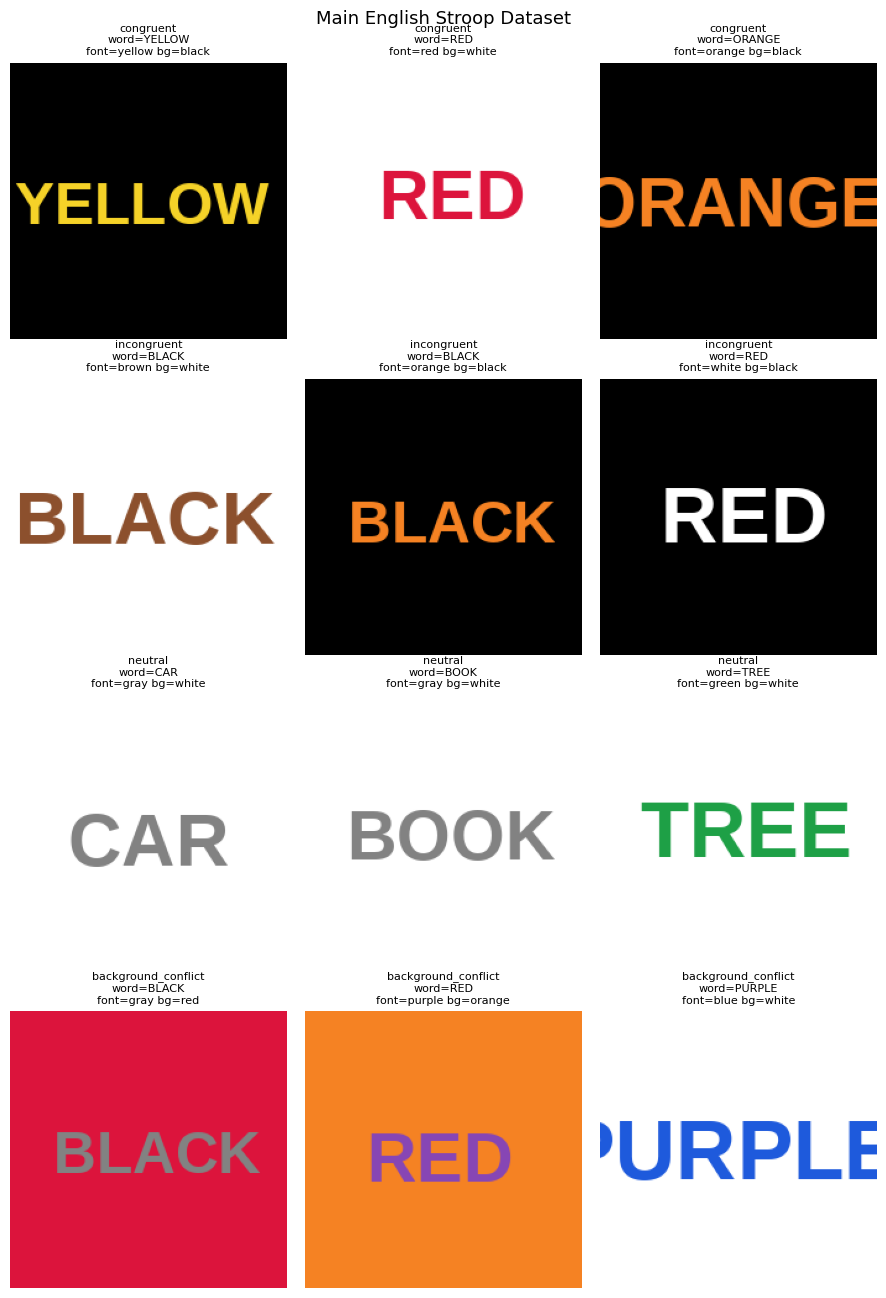

In [8]:
def show_condition_examples(df, title, n_per_condition=3):
    selected_rows = []

    available_conditions = [c for c in CONDITIONS if c in df["condition"].unique()]

    for condition in available_conditions:
        subset = df[df["condition"] == condition]
        selected_rows.extend(
            subset.sample(min(n_per_condition, len(subset)), random_state=SEED).to_dict("records")
        )

    fig, axes = plt.subplots(
        len(available_conditions),
        n_per_condition,
        figsize=(3 * n_per_condition, 3.3 * len(available_conditions))
    )

    if len(available_conditions) == 1:
        axes = np.array([axes])

    for r, condition in enumerate(available_conditions):
        condition_rows = [row for row in selected_rows if row["condition"] == condition]

        for c in range(n_per_condition):
            ax = axes[r, c]

            if c < len(condition_rows):
                row = condition_rows[c]
                img = Image.open(row["image_path"]).convert("RGB")
                ax.imshow(img)
                ax.set_title(
                    f"{condition}\nword={row['word']}\nfont={row['font_color']} bg={row['background_color']}",
                    fontsize=8
                )

            ax.axis("off")

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


show_condition_examples(main_df, "Main English Stroop Dataset", n_per_condition=3)

# 7. Load CLIP

This notebook starts with CLIP because:

```text
1. it is fast to run in Colab,
2. it supports image-text similarity scoring,
3. it gives a clean baseline before testing larger VLMs.
```

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

CLIP_MODEL_NAME = "ViT-B/16"

clip_model, clip_preprocess = clip.load(CLIP_MODEL_NAME, device=device, jit=False)
clip_model.eval()

print("Loaded CLIP model:", CLIP_MODEL_NAME)

Device: cuda


100%|████████████████████████████████████████| 335M/335M [00:01<00:00, 305MiB/s]


Loaded CLIP model: ViT-B/16


# 8. CLIP Evaluation Helper Functions

These functions evaluate CLIP on the Stroop task.

For a prompt template like:

```text
the ink color of the text is {}
```

the code creates candidate prompts:

```text
the ink color of the text is red
the ink color of the text is blue
...
the ink color of the text is white
```

CLIP selects the color with the highest similarity score.

In [15]:
class ImageDatasetForCLIP(Dataset):
    """Dataset wrapper that loads images for CLIP."""

    def __init__(self, dataframe, preprocess):
        self.dataframe = dataframe.reset_index(drop=True)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.preprocess(image)
        return image_tensor, idx


def categorize_color_prediction(row):
    """
    Categorize prediction into:
    - correct_font_color
    - word_bias
    - background_bias
    - other_error
    """

    pred = row["pred_color"]
    font_color = row["font_color"]
    word_color = row.get("word_color", "")
    background_color = row["background_color"]

    if pred == font_color:
        return "correct_font_color"
    elif isinstance(word_color, str) and len(word_color) > 0 and pred == word_color:
        return "word_bias"
    elif pred == background_color:
        return "background_bias"
    else:
        return "other_error"


def evaluate_clip_color_prompt(df, prompt_template, prompt_key, batch_size=128):
    """
    Evaluate CLIP with one prompt template over all 10 color labels.

    Example prompt template:
        "the ink color of the text is {}"

    Candidate prompts:
        the ink color of the text is red
        the ink color of the text is blue
        ...
        the ink color of the text is white
    """

    eval_df = df.reset_index(drop=True).copy()

    candidate_prompts = [prompt_template.format(color) for color in COLOR_NAMES]

    with torch.no_grad():
        text_tokens = clip.tokenize(candidate_prompts).to(device)
        text_features = clip_model.encode_text(text_tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    dataset = ImageDatasetForCLIP(eval_df, clip_preprocess)

    # num_workers=0 avoids Colab multiprocessing shutdown errors.
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device == "cuda")
    )

    pred_colors = []
    pred_scores = []

    for images, indices in tqdm(loader, desc=f"CLIP prompt: {prompt_key}"):
        images = images.to(device, non_blocking=True)

        with torch.no_grad():
            image_features = clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            similarity = image_features @ text_features.T
            best_scores, best_indices = similarity.max(dim=1)

        for score, pred_idx in zip(best_scores.cpu().numpy(), best_indices.cpu().numpy()):
            pred_colors.append(COLOR_NAMES[int(pred_idx)])
            pred_scores.append(float(score))

    eval_df["prompt_key"] = prompt_key
    eval_df["prompt_template"] = prompt_template
    eval_df["pred_color"] = pred_colors
    eval_df["pred_score"] = pred_scores
    eval_df["is_correct"] = eval_df["pred_color"] == eval_df["font_color"]
    eval_df["error_type"] = eval_df.apply(categorize_color_prediction, axis=1)

    return eval_df

# 9. Experiment 1: Prompt Robustness Testing

This is the most important immediate update.

## Why?

The original prompt may be ambiguous:

```text
the text is written in {color}
```

So we test a prompt battery.

## Prompt battery

| Prompt key | Prompt template | Purpose |
|---|---|---|
| `ambiguous_written_in` | `the text is written in {}` | original prompt |
| `ink_color` | `the ink color of the text is {}` | clear font/ink color prompt |
| `font_color` | `the font color is {}` | clear font color prompt |
| `letters_color` | `letters written in {} color` | clear letter-color prompt |
| `word_oriented_control` | `a photo of the word "{}"` | deliberately word-oriented control |
| `minimal_control` | `{}` | minimal prompt control |

## What we report

For each prompt template:

```text
1. overall accuracy
2. accuracy by condition
3. word-bias rate in incongruent condition
4. word-bias rate in background-conflict condition
```

In [16]:
all_prompt_results = []

for prompt_key, prompt_template in PROMPT_TEMPLATES.items():
    result_df = evaluate_clip_color_prompt(
        df=main_df,
        prompt_template=prompt_template,
        prompt_key=prompt_key,
        batch_size=128
    )

    all_prompt_results.append(result_df)

prompt_results_df = pd.concat(all_prompt_results, ignore_index=True)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

prompt_predictions_path = RESULTS_DIR / "clip_prompt_battery_predictions.csv"
prompt_results_df.to_csv(prompt_predictions_path, index=False)

print("Saved prompt-battery predictions:", prompt_predictions_path)
display(prompt_results_df.head())

CLIP prompt: ambiguous_written_in:   0%|          | 0/157 [00:00<?, ?it/s]

CLIP prompt: ink_color:   0%|          | 0/157 [00:00<?, ?it/s]

CLIP prompt: font_color:   0%|          | 0/157 [00:00<?, ?it/s]

CLIP prompt: letters_color:   0%|          | 0/157 [00:00<?, ?it/s]

CLIP prompt: word_oriented_control:   0%|          | 0/157 [00:00<?, ?it/s]

CLIP prompt: minimal_control:   0%|          | 0/157 [00:00<?, ?it/s]

Saved prompt-battery predictions: /content/stroop_expanded_vlm/results/clip_prompt_battery_predictions.csv


,image_id,image_path,mask_path,dataset,script,condition,word,word_color,font_color,background_color,label,prompt_key,prompt_template,pred_color,pred_score,is_correct,error_type
0,congruent_00000,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,BLUE,blue,blue,white,blue,ambiguous_written_in,the text is written in {},blue,0.305420,True,correct_font_color
1,congruent_00001,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,YELLOW,yellow,yellow,black,yellow,ambiguous_written_in,the text is written in {},yellow,0.310303,True,correct_font_color
2,congruent_00002,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,BLUE,blue,blue,white,blue,ambiguous_written_in,the text is written in {},blue,0.289062,True,correct_font_color
3,congruent_00003,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,BLACK,black,black,white,black,ambiguous_written_in,the text is written in {},black,0.292969,True,correct_font_color
4,congruent_00004,/content/stroop_expanded_vlm/main_stroop_20k/i...,/content/stroop_expanded_vlm/main_stroop_20k/m...,main_stroop_20k,english,congruent,RED,red,red,white,red,ambiguous_written_in,the text is written in {},red,0.282959,True,correct_font_color


# 10. Prompt Robustness Summary Table

This table directly answers:

> Does word bias remain high even when the prompt clearly asks for ink/font color?

If yes, then the result is less likely to be only a prompt artifact.

If no, then the prompt wording is strongly affecting the result, which is also important.

In [17]:
def make_prompt_robustness_summary(prompt_results_df):
    rows = []

    for prompt_key, group in prompt_results_df.groupby("prompt_key"):
        row = {
            "prompt_key": prompt_key,
            "prompt_template": group["prompt_template"].iloc[0],
            "overall_accuracy": group["is_correct"].mean(),
        }

        # Accuracy by condition
        for condition in CONDITIONS:
            subset = group[group["condition"] == condition]
            row[f"{condition}_accuracy"] = subset["is_correct"].mean() if len(subset) else np.nan

        # Word-bias rate for key conflict conditions
        for condition in ["incongruent", "background_conflict"]:
            subset = group[group["condition"] == condition]
            row[f"{condition}_word_bias_rate"] = (
                subset["error_type"] == "word_bias"
            ).mean() if len(subset) else np.nan

        rows.append(row)

    return pd.DataFrame(rows)


prompt_summary_df = make_prompt_robustness_summary(prompt_results_df)

prompt_summary_path = RESULTS_DIR / "clip_prompt_robustness_summary.csv"
prompt_summary_df.to_csv(prompt_summary_path, index=False)

print("Saved prompt robustness summary:", prompt_summary_path)
display(prompt_summary_df)

Saved prompt robustness summary: /content/stroop_expanded_vlm/results/clip_prompt_robustness_summary.csv


,prompt_key,prompt_template,overall_accuracy,congruent_accuracy,incongruent_accuracy,neutral_accuracy,background_conflict_accuracy,incongruent_word_bias_rate,background_conflict_word_bias_rate
0,ambiguous_written_in,the text is written in {},0.44515,1.0,0.0312,0.7354,0.0140,0.9688,0.9518
1,font_color,the font color is {},0.47805,1.0,0.0724,0.8072,0.0326,0.9276,0.9280
2,ink_color,the ink color of the text is {},0.48765,1.0,0.0950,0.7982,0.0574,0.9050,0.8592
3,letters_color,letters written in {} color,0.45050,1.0,0.0106,0.7876,0.0038,0.9894,0.9856
4,minimal_control,{},0.43580,1.0,0.0004,0.7412,0.0016,0.9996,0.9942
5,word_oriented_control,"a photo of the word ""{}""",0.43545,1.0,0.0000,0.7418,0.0000,1.0000,1.0000


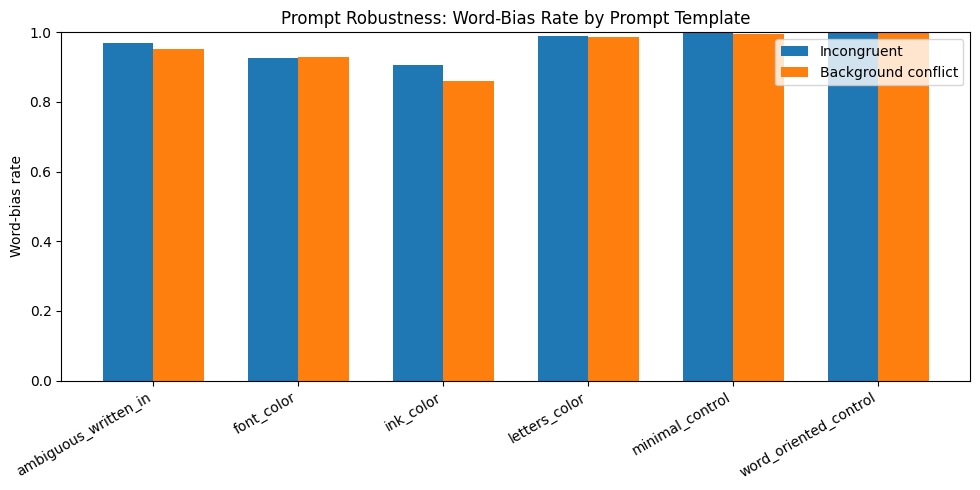

Saved plot: /content/stroop_expanded_vlm/results/prompt_robustness_word_bias_plot.png


In [18]:
plt.figure(figsize=(10, 5))

x = np.arange(len(prompt_summary_df))
width = 0.35

plt.bar(
    x - width / 2,
    prompt_summary_df["incongruent_word_bias_rate"],
    width,
    label="Incongruent"
)

plt.bar(
    x + width / 2,
    prompt_summary_df["background_conflict_word_bias_rate"],
    width,
    label="Background conflict"
)

plt.xticks(x, prompt_summary_df["prompt_key"], rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Word-bias rate")
plt.title("Prompt Robustness: Word-Bias Rate by Prompt Template")
plt.legend()
plt.tight_layout()

plot_path = RESULTS_DIR / "prompt_robustness_word_bias_plot.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

# 11. Experiment 2: Standard Text-Meaning Recognition Control

Ziquan suggested that we should be careful with calling this OCR, because OCR can mean low-level character extraction.

Instead, this section creates a cleaner **text-meaning recognition** control.

## Setup

All images use:

```text
black text on white background
```

The text can be:

```text
1. color words: red, blue, green, ...
2. neutral object words: dog, cat, ship, ...
```

The task is:

> What word is written in the image?

This helps us measure whether the model can recognize textual meaning in a clean setting.

In [19]:
TEXT_MEANING_WORDS = COLOR_NAMES + [w.lower() for w in NEUTRAL_WORDS]

def generate_text_meaning_control_dataset():
    image_dir = TEXT_MEANING_DIR / "images"
    mask_dir = TEXT_MEANING_DIR / "masks"

    if REGENERATE_DATASETS and TEXT_MEANING_DIR.exists():
        shutil.rmtree(TEXT_MEANING_DIR)

    image_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    records = []

    for word in TEXT_MEANING_WORDS:
        for i in range(TEXT_MEANING_SAMPLES_PER_WORD):
            image, mask = draw_text_image(
                word=word.upper(),
                font_color="black",
                background_color="white",
                image_size=IMAGE_SIZE,
                script="latin"
            )

            image_id = f"textmeaning_{word}_{i:04d}"
            image_path, mask_path = save_sample(image, mask, image_id, image_dir, mask_dir)

            records.append({
                "image_id": image_id,
                "image_path": image_path,
                "mask_path": mask_path,
                "dataset": "text_meaning_control",
                "script": "english",
                "word": word,
                "label_word": word,
                "font_color": "black",
                "background_color": "white",
                "word_type": "color" if word in COLOR_NAMES else "neutral_object",
            })

    df = pd.DataFrame(records)
    df.to_csv(TEXT_MEANING_DIR / "metadata.csv", index=False)

    return df


text_meaning_df = generate_text_meaning_control_dataset()

print("Text-meaning control dataset shape:", text_meaning_df.shape)
display(text_meaning_df.head())
display(text_meaning_df["word_type"].value_counts())

Text-meaning control dataset shape: (2000, 10)


,image_id,image_path,mask_path,dataset,script,word,label_word,font_color,background_color,word_type
0,textmeaning_red_0000,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color
1,textmeaning_red_0001,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color
2,textmeaning_red_0002,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color
3,textmeaning_red_0003,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color
4,textmeaning_red_0004,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color


,count
word_type,
color,1000
neutral_object,1000


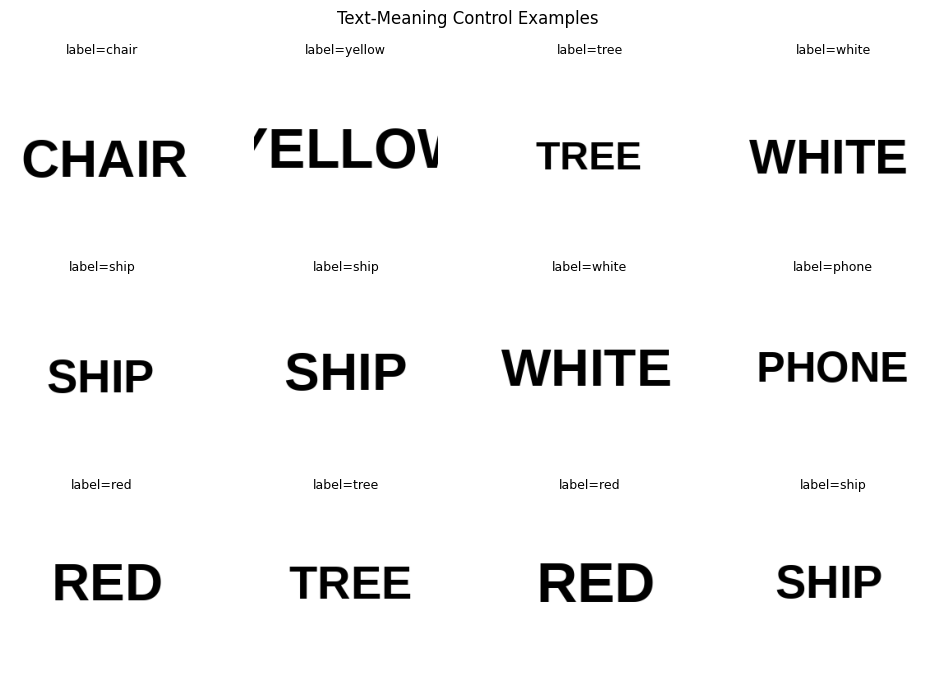

In [20]:
sample_rows = text_meaning_df.sample(12, random_state=SEED).to_dict("records")

fig, axes = plt.subplots(3, 4, figsize=(10, 7))

for ax, row in zip(axes.flatten(), sample_rows):
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"label={row['label_word']}", fontsize=9)
    ax.axis("off")

plt.suptitle("Text-Meaning Control Examples")
plt.tight_layout()
plt.show()

# 12. Evaluate CLIP on Text-Meaning Control

For CLIP, we use candidate prompts such as:

```text
the word says red
the word says dog
the word says ship
...
```

Then CLIP selects which word prompt best matches the image.

In [21]:
TEXT_RECOGNITION_PROMPT = "the word says {}"

def evaluate_clip_text_meaning(df, candidate_words, prompt_template=TEXT_RECOGNITION_PROMPT, batch_size=128):
    eval_df = df.reset_index(drop=True).copy()

    candidate_prompts = [prompt_template.format(word) for word in candidate_words]

    with torch.no_grad():
        text_tokens = clip.tokenize(candidate_prompts).to(device)
        text_features = clip_model.encode_text(text_tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    dataset = ImageDatasetForCLIP(eval_df, clip_preprocess)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    pred_words = []
    pred_scores = []

    for images, indices in tqdm(loader, desc="CLIP text-meaning control"):
        images = images.to(device)

        with torch.no_grad():
            image_features = clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            similarity = image_features @ text_features.T
            best_scores, best_indices = similarity.max(dim=1)

        for score, pred_idx in zip(best_scores.cpu().numpy(), best_indices.cpu().numpy()):
            pred_words.append(candidate_words[int(pred_idx)])
            pred_scores.append(float(score))

    eval_df["text_prompt_template"] = prompt_template
    eval_df["pred_word"] = pred_words
    eval_df["pred_score"] = pred_scores
    eval_df["is_correct_word"] = eval_df["pred_word"] == eval_df["label_word"]

    return eval_df


text_meaning_results_df = evaluate_clip_text_meaning(
    df=text_meaning_df,
    candidate_words=TEXT_MEANING_WORDS,
    prompt_template=TEXT_RECOGNITION_PROMPT,
    batch_size=128
)

text_meaning_predictions_path = RESULTS_DIR / "clip_text_meaning_control_predictions.csv"
text_meaning_results_df.to_csv(text_meaning_predictions_path, index=False)

print("Saved text-meaning predictions:", text_meaning_predictions_path)
display(text_meaning_results_df.head())

CLIP text-meaning control:   0%|          | 0/16 [00:00<?, ?it/s]

Saved text-meaning predictions: /content/stroop_expanded_vlm/results/clip_text_meaning_control_predictions.csv


,image_id,image_path,mask_path,dataset,script,word,label_word,font_color,background_color,word_type,text_prompt_template,pred_word,pred_score,is_correct_word
0,textmeaning_red_0000,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color,the word says {},red,0.334717,True
1,textmeaning_red_0001,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color,the word says {},red,0.340088,True
2,textmeaning_red_0002,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color,the word says {},red,0.335205,True
3,textmeaning_red_0003,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color,the word says {},red,0.325439,True
4,textmeaning_red_0004,/content/stroop_expanded_vlm/text_meaning_cont...,/content/stroop_expanded_vlm/text_meaning_cont...,text_meaning_control,english,red,red,black,white,color,the word says {},red,0.336670,True


In [22]:
text_meaning_overall_acc = text_meaning_results_df["is_correct_word"].mean()

text_meaning_by_type = (
    text_meaning_results_df
    .groupby("word_type")["is_correct_word"]
    .mean()
    .reset_index()
    .rename(columns={"is_correct_word": "text_meaning_accuracy"})
)

text_meaning_by_word = (
    text_meaning_results_df
    .groupby("label_word")["is_correct_word"]
    .mean()
    .reset_index()
    .rename(columns={"is_correct_word": "text_meaning_accuracy"})
    .sort_values("text_meaning_accuracy")
)

print(f"Overall text-meaning recognition accuracy: {text_meaning_overall_acc:.4f}")
display(text_meaning_by_type)
display(text_meaning_by_word)

text_meaning_by_type.to_csv(RESULTS_DIR / "clip_text_meaning_accuracy_by_type.csv", index=False)
text_meaning_by_word.to_csv(RESULTS_DIR / "clip_text_meaning_accuracy_by_word.csv", index=False)

Overall text-meaning recognition accuracy: 1.0000


,word_type,text_meaning_accuracy
0,color,1.0
1,neutral_object,1.0


,label_word,text_meaning_accuracy
0,black,1.0
1,blue,1.0
2,book,1.0
3,brown,1.0
4,car,1.0
5,cat,1.0
6,chair,1.0
7,dog,1.0
8,gray,1.0
9,green,1.0


# 13. Experiment 3: Multilingual / Cross-Script Stroop Test

Ziquan mentioned that the multilingual test is very interesting and should be tried.

This section creates Stroop images in:

```text
1. English
2. Chinese
```

## Why this matters

If a model can understand a script, then the written word may interfere more strongly.

If a model cannot understand a script, then the word meaning may interfere less.

## Example

Chinese color word:

```text
红色 = red
```

If the image shows:

```text
word meaning = red
font color = blue
correct answer = blue
```

and the model predicts red, then it is following the word meaning.

In [23]:
def get_script_word(color, script):
    if script == "english":
        return color.upper()
    elif script == "chinese":
        return CHINESE_COLOR_WORDS[color]
    else:
        raise ValueError("Unsupported script: " + script)


def make_multilingual_sample(script, condition, idx, image_dir, mask_dir):
    if condition == "congruent":
        font_color = random.choice(COLOR_NAMES)
        word_color = font_color
        background_color = choose_contrast_background(font_color)

    elif condition == "incongruent":
        font_color = random.choice(COLOR_NAMES)
        word_color = choose_different_color([font_color])
        background_color = choose_contrast_background(font_color)

    elif condition == "background_conflict":
        font_color = random.choice(COLOR_NAMES)
        word_color = choose_different_color([font_color])
        background_color = choose_different_color([font_color, word_color])

    else:
        raise ValueError("Multilingual test uses congruent, incongruent, and background_conflict only.")

    word = get_script_word(word_color, script)

    image, mask = draw_text_image(
        word=word,
        font_color=font_color,
        background_color=background_color,
        image_size=IMAGE_SIZE,
        script="chinese" if script == "chinese" else "latin"
    )

    image_id = f"{script}_{condition}_{idx:05d}"
    image_path, mask_path = save_sample(image, mask, image_id, image_dir, mask_dir)

    return {
        "image_id": image_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "dataset": "multilingual_stroop",
        "script": script,
        "condition": condition,
        "word": word,
        "word_color": word_color,
        "font_color": font_color,
        "background_color": background_color,
        "label": font_color,
    }


def generate_multilingual_stroop_dataset(scripts=("english", "chinese")):
    image_dir = MULTILINGUAL_DIR / "images"
    mask_dir = MULTILINGUAL_DIR / "masks"

    if REGENERATE_DATASETS and MULTILINGUAL_DIR.exists():
        shutil.rmtree(MULTILINGUAL_DIR)

    image_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    records = []
    multilingual_conditions = ["congruent", "incongruent", "background_conflict"]

    for script in scripts:
        for condition in multilingual_conditions:
            print(f"Generating script={script}, condition={condition}")
            for i in tqdm(range(MULTILINGUAL_NUM_PER_CONDITION)):
                records.append(make_multilingual_sample(script, condition, i, image_dir, mask_dir))

    df = pd.DataFrame(records)
    df.to_csv(MULTILINGUAL_DIR / "metadata.csv", index=False)

    return df


multilingual_df = generate_multilingual_stroop_dataset(scripts=("english", "chinese"))

print("Multilingual dataset shape:", multilingual_df.shape)
display(multilingual_df.head())
display(multilingual_df.groupby(["script", "condition"]).size())

Generating script=english, condition=congruent


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating script=english, condition=incongruent


  0%|          | 0/1000 [00:00<?, ?it/s]

Generating script=english, condition=background_conflict


...

Generating script=chinese, condition=background_conflict


  0%|          | 0/1000 [00:00<?, ?it/s]

Multilingual dataset shape: (6000, 11)


,image_id,image_path,mask_path,dataset,script,condition,word,word_color,font_color,background_color,label
0,english_congruent_00000,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,GREEN,green,green,white,green
1,english_congruent_00001,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,BROWN,brown,brown,white,brown
2,english_congruent_00002,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,PURPLE,purple,purple,white,purple
3,english_congruent_00003,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,ORANGE,orange,orange,black,orange
4,english_congruent_00004,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,BLUE,blue,blue,white,blue


script   condition          
chinese  background_conflict    1000
         congruent              1000
         incongruent            1000
english  background_conflict    1000
         congruent              1000
         incongruent            1000
dtype: int64

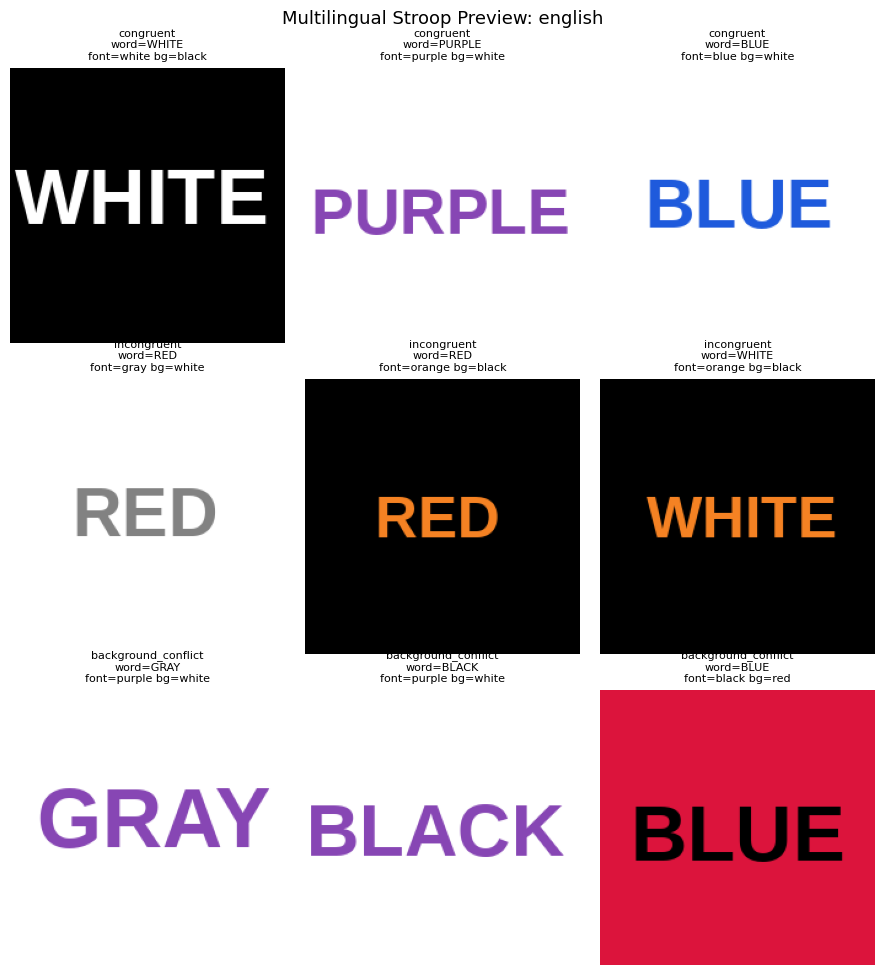

/tmp/ipykernel_1588/2895365734.py:39: UserWarning: Glyph 28784 (\N{CJK UNIFIED IDEOGRAPH-7070}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1588/2895365734.py:39: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1588/2895365734.py:39: UserWarning: Glyph 32418 (\N{CJK UNIFIED IDEOGRAPH-7EA2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1588/2895365734.py:39: UserWarning: Glyph 26837 (\N{CJK UNIFIED IDEOGRAPH-68D5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1588/2895365734.py:39: UserWarning: Glyph 40644 (\N{CJK UNIFIED IDEOGRAPH-9EC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1588/2895365734.py:39: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1588/2895365734.py:39: UserWarning: Glyph 27225 (\N{CJK UNIFIED IDEOGRAPH-6A59}

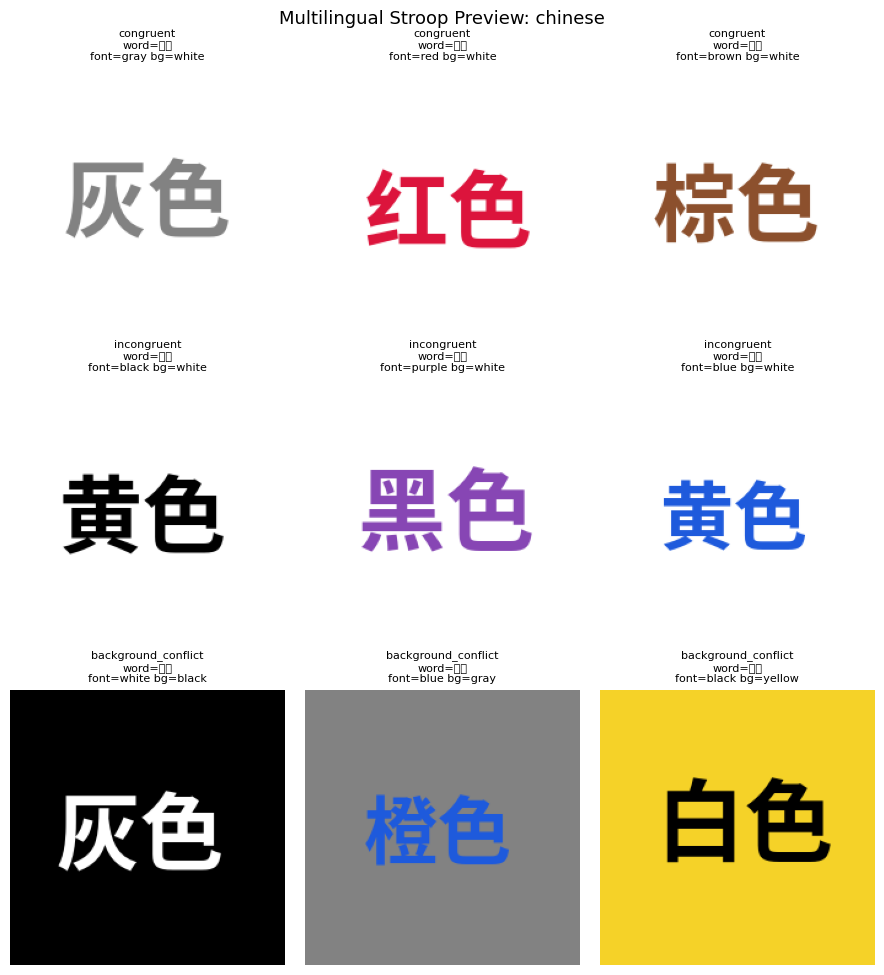

In [24]:
# Preview multilingual examples
for script in ["english", "chinese"]:
    subset = multilingual_df[multilingual_df["script"] == script]
    show_condition_examples(subset, f"Multilingual Stroop Preview: {script}", n_per_condition=3)

# 14. Evaluate CLIP on Multilingual Stroop

For the color-recognition task, we use a clearer prompt:

```text
the ink color of the text is {color}
```

This avoids the ambiguity of the original prompt.

We then compare word-bias rates between English and Chinese.

In [25]:
multilingual_results_df = evaluate_clip_color_prompt(
    df=multilingual_df,
    prompt_template=PROMPT_TEMPLATES[MAIN_COLOR_PROMPT_KEY],
    prompt_key=f"multilingual_{MAIN_COLOR_PROMPT_KEY}",
    batch_size=128
)

multilingual_predictions_path = RESULTS_DIR / "clip_multilingual_stroop_predictions.csv"
multilingual_results_df.to_csv(multilingual_predictions_path, index=False)

print("Saved multilingual predictions:", multilingual_predictions_path)
display(multilingual_results_df.head())

CLIP prompt: multilingual_ink_color:   0%|          | 0/47 [00:00<?, ?it/s]

Saved multilingual predictions: /content/stroop_expanded_vlm/results/clip_multilingual_stroop_predictions.csv


,image_id,image_path,mask_path,dataset,script,condition,word,word_color,font_color,background_color,label,prompt_key,prompt_template,pred_color,pred_score,is_correct,error_type
0,english_congruent_00000,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,GREEN,green,green,white,green,multilingual_ink_color,the ink color of the text is {},green,0.273193,True,correct_font_color
1,english_congruent_00001,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,BROWN,brown,brown,white,brown,multilingual_ink_color,the ink color of the text is {},brown,0.259033,True,correct_font_color
2,english_congruent_00002,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,PURPLE,purple,purple,white,purple,multilingual_ink_color,the ink color of the text is {},purple,0.312256,True,correct_font_color
3,english_congruent_00003,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,ORANGE,orange,orange,black,orange,multilingual_ink_color,the ink color of the text is {},orange,0.298340,True,correct_font_color
4,english_congruent_00004,/content/stroop_expanded_vlm/multilingual_stro...,/content/stroop_expanded_vlm/multilingual_stro...,multilingual_stroop,english,congruent,BLUE,blue,blue,white,blue,multilingual_ink_color,the ink color of the text is {},blue,0.287354,True,correct_font_color


In [26]:
multilingual_summary_df = (
    multilingual_results_df
    .groupby(["script", "condition"])
    .agg(
        accuracy=("is_correct", "mean"),
        word_bias_rate=("error_type", lambda x: (x == "word_bias").mean()),
        background_bias_rate=("error_type", lambda x: (x == "background_bias").mean()),
        other_error_rate=("error_type", lambda x: (x == "other_error").mean()),
    )
    .reset_index()
)

multilingual_summary_path = RESULTS_DIR / "clip_multilingual_summary.csv"
multilingual_summary_df.to_csv(multilingual_summary_path, index=False)

print("Saved multilingual summary:", multilingual_summary_path)
display(multilingual_summary_df)

Saved multilingual summary: /content/stroop_expanded_vlm/results/clip_multilingual_summary.csv


,script,condition,accuracy,word_bias_rate,background_bias_rate,other_error_rate
0,chinese,background_conflict,0.302,0.001,0.680,0.017
1,chinese,congruent,0.806,0.000,0.087,0.107
2,chinese,incongruent,0.789,0.019,0.088,0.104
3,english,background_conflict,0.085,0.817,0.098,0.000
4,english,congruent,1.000,0.000,0.000,0.000
5,english,incongruent,0.100,0.900,0.000,0.000


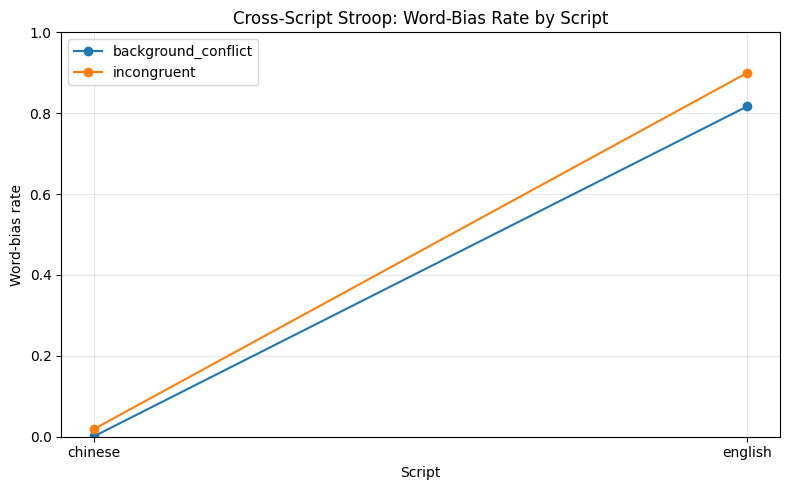

Saved plot: /content/stroop_expanded_vlm/results/cross_script_word_bias_plot.png


In [27]:
plot_df = multilingual_summary_df[
    multilingual_summary_df["condition"].isin(["incongruent", "background_conflict"])
]

plt.figure(figsize=(8, 5))

for condition in plot_df["condition"].unique():
    sub = plot_df[plot_df["condition"] == condition]
    plt.plot(sub["script"], sub["word_bias_rate"], marker="o", label=condition)

plt.ylim(0, 1)
plt.xlabel("Script")
plt.ylabel("Word-bias rate")
plt.title("Cross-Script Stroop: Word-Bias Rate by Script")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = RESULTS_DIR / "cross_script_word_bias_plot.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

# 15. Optional Experiment 4: Qwen2.5-VL-3B Black-Box Evaluation

This section is optional.

CLIP is evaluated using image-text similarity.  
Qwen2.5-VL is an instruction-following vision-language model, so we ask it a direct question.

## Why start small?

Advanced VLMs are slower and require more memory.

Start with:

```text
QWEN_SAMPLE_SIZE = 100
```

Then increase it later if the runtime is stable.

## Task prompt

The model is asked:

```text
What is the ink/font color of the text in this image?
Answer with exactly one color from the list.
```

The output is parsed into one of the 10 color labels.

In [28]:
# Run this setup only if you want to test Qwen2.5-VL.
# Keep this False for normal CLIP-only runs.

RUN_QWEN_SETUP = False

if RUN_QWEN_SETUP:
    !pip -q install -U "transformers>=4.51.0" accelerate qwen-vl-utils

In [29]:
# Optional Qwen2.5-VL evaluation.
# Change RUN_QWEN_EVAL to True only after running the setup cell above.

RUN_QWEN_EVAL = False

QWEN_MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
QWEN_SAMPLE_SIZE = 100

if RUN_QWEN_EVAL:
    from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
    from qwen_vl_utils import process_vision_info

    qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        QWEN_MODEL_ID,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto"
    )

    qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)

    def parse_color_answer(text):
        text_lower = text.lower()
        matches = []

        for color in COLOR_NAMES:
            if re.search(rf"\b{re.escape(color)}\b", text_lower):
                matches.append(color)

        if len(matches) >= 1:
            return matches[0]

        return "unknown"

    def ask_qwen_font_color(image_path):
        prompt = (
            "What is the ink or font color of the text in this image? "
            "Answer with exactly one color from this list: "
            + ", ".join(COLOR_NAMES)
            + ". Do not explain."
        )

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image_path},
                    {"type": "text", "text": prompt},
                ],
            }
        ]

        text = qwen_processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        image_inputs, video_inputs = process_vision_info(messages)

        inputs = qwen_processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )

        inputs = inputs.to(qwen_model.device)

        generated_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False
        )

        generated_ids_trimmed = [
            out_ids[len(in_ids):]
            for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]

        output_text = qwen_processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[0]

        return output_text.strip()

    # Balanced sample across conditions
    qwen_eval_df = (
        main_df
        .groupby("condition", group_keys=False)
        .apply(lambda x: x.sample(
            n=min(QWEN_SAMPLE_SIZE // len(CONDITIONS), len(x)),
            random_state=SEED
        ))
        .reset_index(drop=True)
    )

    qwen_records = []

    for _, row in tqdm(qwen_eval_df.iterrows(), total=len(qwen_eval_df), desc="Qwen2.5-VL evaluation"):
        raw_answer = ask_qwen_font_color(row["image_path"])
        pred_color = parse_color_answer(raw_answer)

        record = row.to_dict()
        record["model"] = QWEN_MODEL_ID
        record["raw_answer"] = raw_answer
        record["pred_color"] = pred_color
        record["is_correct"] = pred_color == row["font_color"]
        record["error_type"] = categorize_color_prediction(record)

        qwen_records.append(record)

    qwen_results_df = pd.DataFrame(qwen_records)

    qwen_predictions_path = RESULTS_DIR / "qwen2_5_vl_3b_stroop_predictions_sample.csv"
    qwen_results_df.to_csv(qwen_predictions_path, index=False)

    print("Saved Qwen predictions:", qwen_predictions_path)
    display(qwen_results_df.head())

    qwen_summary_df = (
        qwen_results_df
        .groupby("condition")
        .agg(
            accuracy=("is_correct", "mean"),
            word_bias_rate=("error_type", lambda x: (x == "word_bias").mean()),
            background_bias_rate=("error_type", lambda x: (x == "background_bias").mean()),
            other_error_rate=("error_type", lambda x: (x == "other_error").mean()),
        )
        .reset_index()
    )

    qwen_summary_path = RESULTS_DIR / "qwen2_5_vl_3b_stroop_summary_sample.csv"
    qwen_summary_df.to_csv(qwen_summary_path, index=False)

    print("Saved Qwen summary:", qwen_summary_path)
    display(qwen_summary_df)

# 16. Final Project Summary

This cell creates a text summary after the experiments finish.

The summary is saved as:

```text
updated_project_summary.txt
```

In [30]:
def create_updated_project_summary():
    lines = []

    lines.append("Updated Stroop-Style VLM Experiment Summary")
    lines.append("=" * 60)
    lines.append("")
    lines.append("This update extends the previous one-prompt CLIP experiment based on supervisor feedback.")
    lines.append("")
    lines.append("New experiments added:")
    lines.append("1. Prompt robustness testing with multiple prompt templates.")
    lines.append("2. Standard text-meaning recognition control with black text.")
    lines.append("3. Multilingual / cross-script Stroop testing with English and Chinese text.")
    lines.append("4. Optional Qwen2.5-VL-3B black-box evaluation on a small subset.")
    lines.append("")

    lines.append("Main 20k dataset:")
    lines.append(f"- Total images: {len(main_df)}")
    lines.append(f"- Color classes: {len(COLOR_NAMES)}")
    lines.append("- Conditions: congruent, incongruent, neutral, background_conflict")
    lines.append("- Correct label: visual font color")
    lines.append("")

    if "prompt_summary_df" in globals():
        lines.append("Prompt robustness summary:")
        for _, row in prompt_summary_df.iterrows():
            lines.append(
                f"- {row['prompt_key']}: "
                f"overall accuracy={row['overall_accuracy']:.4f}, "
                f"incongruent word bias={row['incongruent_word_bias_rate']:.4f}, "
                f"background-conflict word bias={row['background_conflict_word_bias_rate']:.4f}"
            )
        lines.append("")

    if "text_meaning_overall_acc" in globals():
        lines.append(f"Text-meaning control overall accuracy: {text_meaning_overall_acc:.4f}")
        lines.append("")

    if "multilingual_summary_df" in globals():
        lines.append("Multilingual summary:")
        for _, row in multilingual_summary_df.iterrows():
            lines.append(
                f"- script={row['script']}, condition={row['condition']}: "
                f"accuracy={row['accuracy']:.4f}, "
                f"word_bias_rate={row['word_bias_rate']:.4f}"
            )
        lines.append("")

    lines.append("Interpretation:")
    lines.append("The prompt robustness experiment checks whether the observed word bias is due to ambiguous wording or persists with explicit ink/font-color prompts.")
    lines.append("The text-meaning control checks whether the model can recognize written text meaning in a clean black-text condition.")
    lines.append("The multilingual experiment tests whether word-bias changes across scripts such as English and Chinese.")
    lines.append("The optional Qwen2.5-VL section allows the same Stroop-style black-box test to be extended to an instruction-following VLM.")

    return "\n".join(lines)


updated_summary_text = create_updated_project_summary()
print(updated_summary_text)

summary_path = RESULTS_DIR / "updated_project_summary.txt"
with open(summary_path, "w") as f:
    f.write(updated_summary_text)

print("\nSaved summary:", summary_path)

Updated Stroop-Style VLM Experiment Summary

This update extends the previous one-prompt CLIP experiment based on supervisor feedback.

New experiments added:
1. Prompt robustness testing with multiple prompt templates.
2. Standard text-meaning recognition control with black text.
3. Multilingual / cross-script Stroop testing with English and Chinese text.
4. Optional Qwen2.5-VL-3B black-box evaluation on a small subset.

Main 20k dataset:
- Total images: 20000
- Color classes: 10
- Conditions: congruent, incongruent, neutral, background_conflict
- Correct label: visual font color

Prompt robustness summary:
- ambiguous_written_in: overall accuracy=0.4451, incongruent word bias=0.9688, background-conflict word bias=0.9518
- font_color: overall accuracy=0.4780, incongruent word bias=0.9276, background-conflict word bias=0.9280
- ink_color: overall accuracy=0.4876, incongruent word bias=0.9050, background-conflict word bias=0.8592
- letters_color: overall accuracy=0.4505, incongruent wor

In [31]:
from google.colab import drive
from pathlib import Path
import shutil
import datetime

# 1. Mount Google Drive
drive.mount("/content/drive")

# 2. Source results folder
source_results_dir = Path(RESULTS_DIR)

# 3. Destination in Google Drive
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

drive_save_dir = Path("/content/drive/MyDrive/Stroop_CLIP_Results")
drive_save_dir.mkdir(parents=True, exist_ok=True)

zip_base_path = drive_save_dir / f"results_{timestamp}"

# 4. Create zip file
if source_results_dir.exists():
    zip_path = shutil.make_archive(
        base_name=str(zip_base_path),
        format="zip",
        root_dir=str(source_results_dir)
    )

    print("Results zip saved to Google Drive:")
    print(zip_path)
else:
    print("Results folder not found:")
    print(source_results_dir)

Mounted at /content/drive
Results zip saved to Google Drive:
/content/drive/MyDrive/Stroop_CLIP_Results/results_20260801_222811.zip
